<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 1 — Introducción con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->
<font color="#7F000E" size=3> Nivel: Ingeniería Biomédica — 7.º ciclo / 4.º año </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Importación, exploración, visualización y exportación de ECG </font><br>
</div>

---

## Objetivos

Al finalizar este laboratorio, el estudiante será capaz de:

1. Acceder a una base de datos de señales fisiológicas de PhysioNet.
2. Cargar un registro ECG mediante la librería `wfdb`.
3. Identificar la frecuencia de muestreo, número de canales, nombres de canales y duración.
4. Construir el eje temporal de una señal discreta.
5. Visualizar una señal ECG mediante diferentes representaciones.
6. Analizar un segmento de la señal.
7. Exportar un segmento ECG a formato `.wav`.
8. Interpretar las diferencias entre una señal biomédica y una señal de audio.
9. Formular observaciones básicas sobre la morfología y amplitud de un ECG.

> **Importante:** el archivo WAV generado es una representación de la señal ECG en un formato reproducible por herramientas de audio. No significa que el ECG sea originalmente una señal acústica.



## 1. Introducción

Las señales biomédicas son señales generadas por procesos fisiológicos. Algunos ejemplos son:

- ECG — electrocardiograma
- EEG — electroencefalograma
- EMG — electromiograma
- EOG — electrooculograma
- PPG — fotopletismografía

En este laboratorio trabajaremos con una señal **ECG real** obtenida de **PhysioNet**.

PhysioNet proporciona acceso a numerosas bases de datos fisiológicas. Una de las bases más conocidas es la **MIT-BIH Arrhythmia Database**, que contiene registros electrocardiográficos anotados.

### Concepto fundamental: DATABASE + RECORD

Un registro no debe identificarse solamente por su número.

Por ejemplo:

```python
DATABASE = "mitdb"
RECORD = "100"
```

significa que estamos solicitando el registro `100` de la base de datos `mitdb`.

El mismo número de registro puede tener un significado diferente si pertenece a otra base de datos. Por ello, siempre debemos interpretar:

```text
BASE DE DATOS + RECORD
```

como la identificación del registro.



## 2. Parámetros configurables

En esta sección el estudiante podrá cambiar los parámetros principales del laboratorio.

### Parámetros

| Parámetro | Descripción | Ejemplo |
|---|---|---|
| `DATABASE` | Base de datos de PhysioNet | `"mitdb"` |
| `RECORD` | Identificador del registro | `"100"` |
| `CHANNEL` | Canal que se desea analizar | `0` |
| `DURATION` | Duración del segmento en segundos | `10` |
| `OUTPUT_WAV` | Nombre del archivo WAV | `"ecg_100.wav"` |

### Pregunta inicial

Antes de ejecutar el código, responda:

**¿Qué cree que representa `CHANNEL = 0`?**
- CHANNEL = 0 representa el índice del primer canal disponible dentro del registro ECG. En este caso corresponde a la derivación MLII, la cual contiene una medición específica de la actividad eléctrica cardíaca.

Anote su hipótesis y compruébela después de ejecutar el notebook.


In [1]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_0.wav



## 3. Instalación de librerías

Utilizaremos:

- **WFDB:** acceso a registros de PhysioNet.
- **NumPy:** procesamiento numérico.
- **Pandas:** organización de datos.
- **Matplotlib:** visualización.
- **SciPy:** exportación de la señal a WAV.


In [2]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 65.9 MB/s eta 0:00:00


In [3]:

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib


In [4]:

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar el registro desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

Usaremos:

```python
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)
```

El argumento `pn_dir` indica que el registro se obtendrá desde una base de datos disponible en PhysioNet.


In [5]:
DATABASE = "mitdb"
RECORD = "100"

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

Registro cargado correctamente.



## 5. Explorar la información del registro

Antes de procesar una señal biomédica es necesario conocer sus características.

Algunos parámetros importantes son:

- `fs`: frecuencia de muestreo.
- `sig_len`: número de muestras.
- `n_sig`: número de canales.
- `sig_name`: nombres de los canales.
- `units`: unidades de las señales.


In [6]:

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)


INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos



### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro?
- La frecuencia de muestreo es de 360 Hz. Esto significa que el equipo de adquisición tomó 360 muestras por segundo de la señal eléctrica cardíaca.

2. ¿Cuántos canales tiene?
- El registro tiene 2 canales. Esto es estándar en la base MIT-BIH, donde cada registro suele incluir dos derivaciones simultáneas para tener una visión más completa de la actividad eléctrica cardíaca.

3. ¿Cómo se llama el canal seleccionado?
- El canal seleccionado (CHANNEL = 0) se denomina MLII, que corresponde a la derivación modificada de la extremidad izquierda. Es equivalente a la derivación II del ECG estándar de 12 derivaciones y es una de las más utilizadas en monitorización continua porque ofrece una buena visualización de todas las ondas (P, QRS y T).

4. ¿Cuál es la duración total del registro?
La duración total es de 1805.56 segundos, es decir, aproximadamente **30 minutos y 5 segundos. Este tiempo es suficiente para capturar varios eventos cardíacos y es típico de los registros ambulatorios de esta base de datos.

5. Si `fs = 360 Hz`, ¿cuántas muestras se adquieren en 1 segundo?
- Se adquieren 360 muestras en un segundo. Esto se obtiene directamente de la definición de frecuencia de muestreo: una frecuencia de 360 Hz implica 360 ciclos de muestreo (y por tanto 360 muestras) cada segundo.

6. ¿Cuántas muestras corresponden a un segmento de 10 segundos?
- Corresponden 3600 muestras. Se calcula simplemente multiplicando la frecuencia de muestreo por el tiempo: 360 muestras/s × 10 s = 3600 muestras.


## 6. Identificación del canal

El parámetro:

```python
record.sig_name
```

permite conocer qué señal corresponde a cada canal.

Por ejemplo, conceptualmente:

```text
CHANNEL 0 → primer canal
CHANNEL 1 → segundo canal
...
```

No debemos asumir que todos los registros tienen los mismos canales. Siempre debemos consultar los metadatos del registro.


In [7]:
CHANNEL = 0

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII



## 7. Extraer la señal ECG

Las muestras de la señal se encuentran en:

```python
record.p_signal
```

Esta estructura contiene:

```text
filas    → muestras
columnas → canales
```

Por tanto:

```python
signal = record.p_signal[:, CHANNEL]
```

selecciona todas las muestras del canal indicado.


In [8]:

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])


Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]



## 8. Crear el eje temporal

Una señal digital está formada por muestras.

Si la frecuencia de muestreo es:

\[
f_s
\]

entonces el intervalo entre muestras es:

\[
T_s = \frac{1}{f_s}
\]

y el instante asociado a la muestra `n` es:

\[
t[n] = \frac{n}{f_s}
\]

Esta relación es fundamental para interpretar correctamente una señal biomédica.


In [9]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")


Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos



# 9. GRÁFICA 1 — Señal ECG completa

En esta primera visualización observaremos todo el registro.

### Objetivo

Reconocer:

- eje temporal;
- amplitud;
- duración;
- comportamiento general de la señal;
- posibles cambios de morfología.


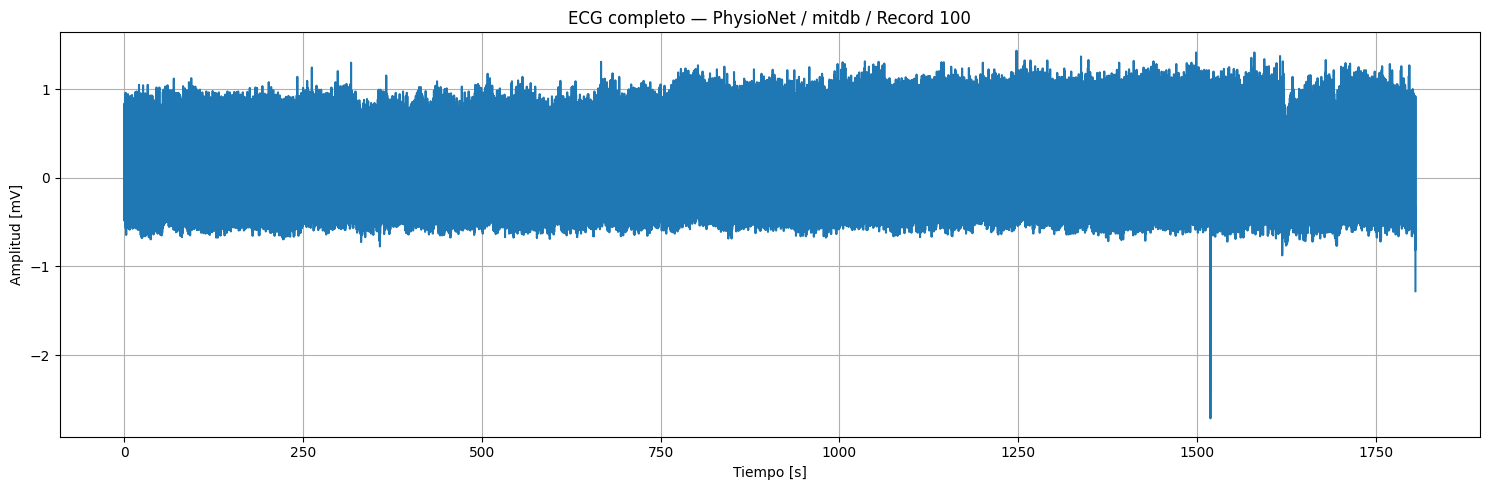

In [10]:

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 2

1. ¿La señal presenta una amplitud constante?
- No. La amplitud de la señal ECG varía con el tiempo debido a las diferentes etapas de la actividad eléctrica cardíaca. Los cambios más notorios corresponden principalmente al complejo QRS, donde se presentan mayores amplitudes.

2. ¿Se pueden identificar visualmente complejos QRS?
- Sí. En la gráfica se pueden observar picos de mayor amplitud asociados al complejo QRS, correspondiente a la despolarización ventricular del corazón.

3. ¿La morfología permanece igual durante todo el registro?
- La morfología mantiene un patrón similar entre los diferentes latidos, aunque pueden existir pequeñas variaciones debido a cambios fisiológicos o ruido presente en la adquisición.

4. ¿Se observa ruido?
- Sí, se observan pequeñas variaciones en la señal que pueden estar asociadas a ruido de adquisición, interferencias o movimientos durante el registro.

5. ¿Qué ventajas tiene visualizar una señal durante varios minutos?
- Permite analizar el comportamiento general del ritmo cardíaco, identificar variaciones entre latidos y detectar posibles eventos anormales durante un periodo prolongado.

6. ¿Qué limitaciones tiene una gráfica demasiado extensa?
- Una gráfica con mucha duración dificulta observar detalles específicos de la señal, como las ondas P, complejo QRS y onda T, por lo que es necesario trabajar con segmentos más pequeños para un análisis detallado.


# 10. GRÁFICA 2 — Segmento ECG ampliado

Una señal completa puede dificultar el análisis de eventos individuales.

Por ello seleccionaremos solamente los primeros `DURATION` segundos.


In [11]:
DURATION = 10

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


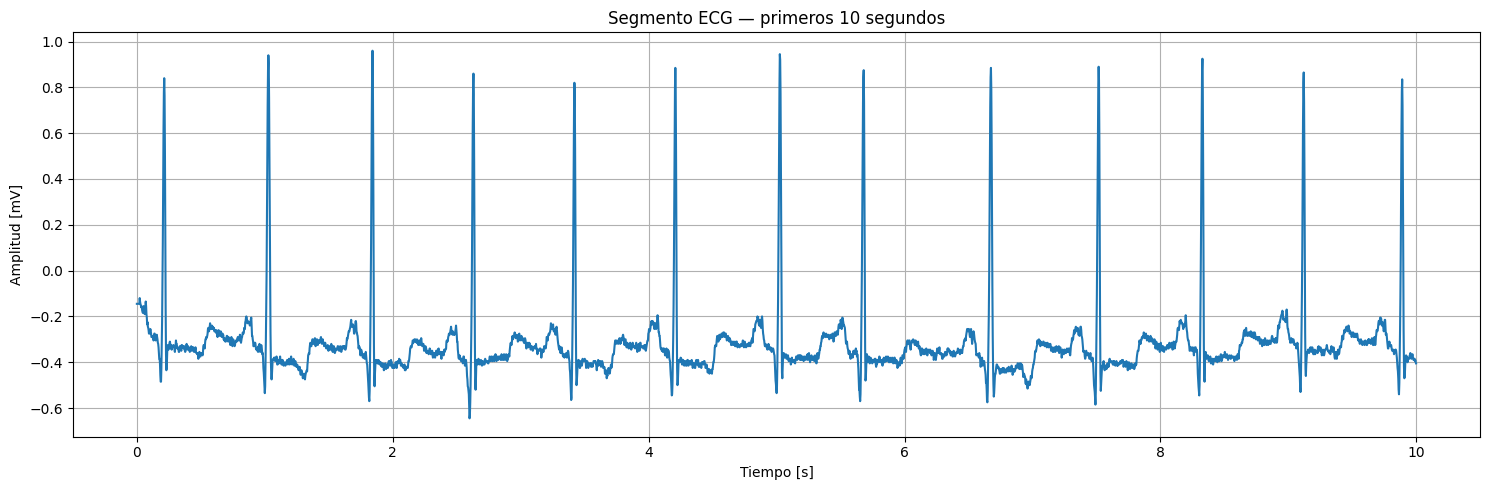

In [12]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Actividad

Observe cuidadosamente la gráfica.

Intente identificar:

- onda P;
- complejo QRS;
- onda T;
- intervalo entre complejos QRS;
- posibles artefactos.

> **Nota:** la identificación automática de ondas no forma parte de este laboratorio. Aquí el objetivo es desarrollar una primera capacidad de observación de señales biomédicas.

Respuesta:

En el segmento ECG de 10 segundos se observan los ciclos cardíacos individuales. Los complejos QRS se identifican como los picos de mayor amplitud, mientras que las ondas P y T presentan amplitudes menores. La separación entre complejos QRS permite analizar la regularidad del ritmo cardíaco y pueden observarse pequeñas variaciones asociadas a ruido o artefactos de adquisición.



# 11. GRÁFICA 3 — Histograma de amplitudes

El histograma permite observar cómo se distribuyen los valores de amplitud de la señal.

Podemos utilizarlo para introducir conceptos como:

- media;
- dispersión;
- valores extremos;
- distribución de amplitudes.


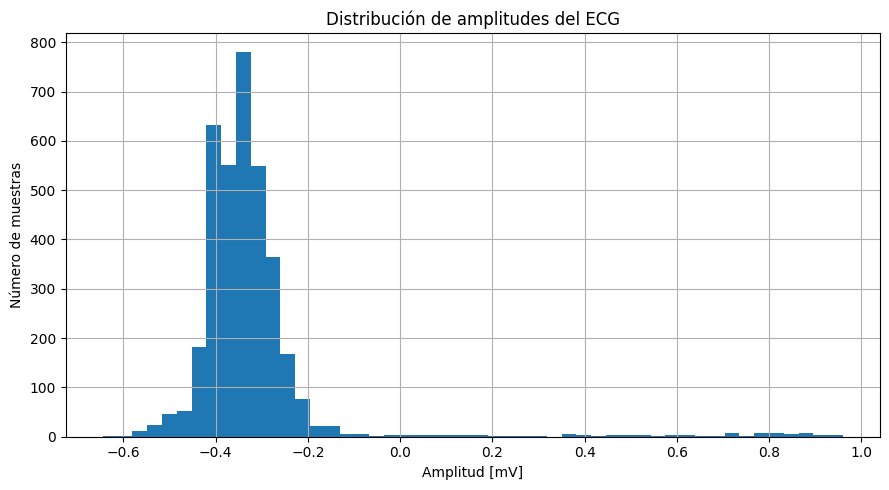

In [13]:

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 3

1. ¿Dónde se concentra la mayor cantidad de muestras?
- La mayor cantidad de muestras se concentra cerca de cero. Esto tiene sentido porque entre cada latido el corazón está en reposo eléctrico y la señal se queda en la línea isoeléctrica, que es aproximadamente cero milivoltios.

2. ¿La distribución parece simétrica?
- No, no es simétrica. Tiene un pico muy alto en el centro y colas hacia los lados. La onda R positiva suele ser más grande que las ondas Q y S negativas, entonces la distribución se inclina un poco.

3. ¿Existen valores extremos?
- Sí, hay valores extremos. Son los picos del complejo QRS, tanto los positivos como los negativos. También puede haber artefactos de movimiento o ruido de la línea de base.

4. ¿Qué podría producir valores de amplitud muy diferentes al valor central?
- Los valores lejanos de cero se producen por los complejos QRS, que son los eventos de mayor amplitud en el ECG. También pueden venir de artefactos de movimiento del paciente o de cambios en la línea de base por la respiración.

5. ¿El histograma conserva información temporal? Explique.
- No, el histograma no guarda información temporal. Solo dice cuántas muestras tienen cierta amplitud, pero no dice en qué momento ocurrieron. No se puede saber la frecuencia cardíaca ni los intervalos entre latidos solo con el histograma. Para eso se necesita la gráfica en el tiempo.



# 12. GRÁFICA 4 — Representación discreta

Una señal digital no solamente puede representarse como una línea continua visualmente.

También podemos observar sus muestras individuales.

Esto permite introducir el concepto:

\[
x[n]
\]

donde `n` representa el índice de muestra.


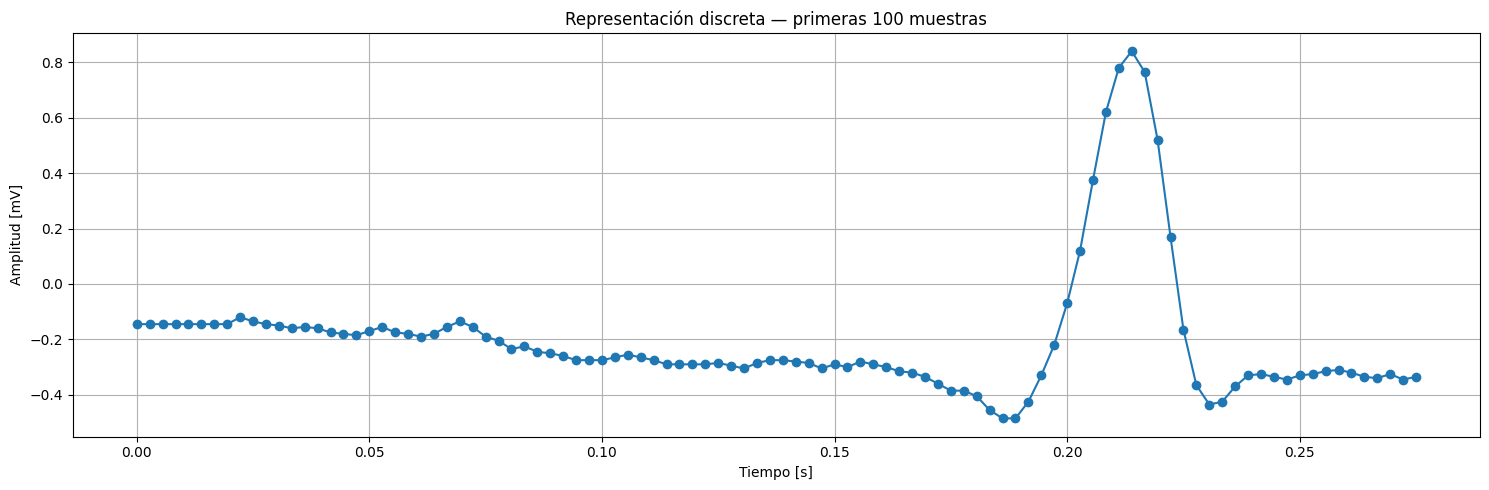

In [14]:

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 4

1. ¿Cuántas muestras existen por segundo?
**Existen 100 muestras**
2. ¿Qué ocurre si aumentamos `fs`?
**Se obtienen más muestras por segundo, y por ende se tendria una mejor resolucion de señal.**
3. ¿Qué ocurre si disminuimos `fs`?
**Se obtienen menos muestras por segundo, y por ende se tendria una menor resolucion de señal.Asimismo, uede producirse aliasing, debido a que no se cumple adecuadamente el criterio de Nyquist.**
4. ¿Qué representa el eje `n` en una señal discreta?
**Representa el índice o número de cada muestra de una señal discreta. Cada valor de (n) identifica una muestra específica de la señal.**
5. ¿Cuál es la relación entre `n`, `fs` y `t`?
**El índice n indica el número de la muestra, fs indica cuántas muestras se toman por segundo y t indica el tiempo correspondiente a cada muestra. Por lo tanto, el tiempo depende del número de muestra y de la frecuencia de muestreo.**



# 13. Estadística básica de la señal

Antes de exportar la señal calcularemos algunos parámetros básicos.


In [15]:

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3199
Desviación estándar: 0.1702
Mínimo            : -0.6450
Máximo            : 0.9600
Rango             : 1.6050



# 14. Convertir ECG a archivo WAV

El formato WAV es común en aplicaciones de audio. Sin embargo, nuestra señal es un ECG.

Para poder almacenarla como WAV realizaremos:

```text
ECG original
     ↓
Eliminar componente media
     ↓
Normalizar amplitud
     ↓
Convertir a int16
     ↓
Guardar WAV
```

### ¿Por qué normalizar?

Los valores del ECG están expresados en unidades fisiológicas, mientras que el WAV suele utilizar representaciones enteras, como `int16`.

Utilizaremos el rango:

\[
-32768 \leq x \leq 32767
\]

para `int16`.


In [16]:

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")


Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -8322
Máximo int16    : 32767



# 15. Guardar el archivo WAV

La frecuencia de muestreo del WAV será la misma frecuencia de muestreo del registro ECG.

Esto es importante porque permite conservar la separación temporal entre las muestras.


In [17]:
RECORD = "100"
CHANNEL = 0
OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)

Archivo WAV generado correctamente:
ecg_record_100_channel_0.wav



# 16. Reproducir el archivo WAV

En Google Colab/Jupyter podemos utilizar un reproductor integrado.


In [18]:

# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)



### Preguntas de análisis 5

1. ¿Puede escuchar claramente la señal?
- Sí se puede escuchar, pero no es un sonido musical. Se escuchan golpes rítmicos repetidos, uno por cada latido. La velocidad de los golpes corresponde a la frecuencia cardíaca del paciente.

2. ¿El sonido corresponde a un sonido fisiológico real?
- No. El ECG es una señal eléctrica, no de sonido. Lo que escuchamos es una conversión artificial de voltaje a audio. Los sonidos reales del corazón son los ruidos de las válvulas y se registran con fonocardiografía, no con electrocardiografía.

3. ¿Por qué un ECG puede convertirse a WAV?
- Se puede convertir porque tanto el ECG como el audio son secuencias de números en el tiempo. El formato WAV solo necesita una frecuencia de muestreo y una lista de amplitudes como enteros. Al quitarle la media al ECG, normalizarlo y pasarlo a int16, queda compatible con WAV. El formato no distingue si es sonido o voltaje.

4. ¿Qué información se conserva al hacer la conversión?
- Se conserva la forma de onda y la frecuencia de muestreo original, entonces la separación temporal entre muestras se mantiene igual. Pero se pierde la escala en milivoltios porque el WAV guarda números enteros sin unidades.

5. ¿Qué información fisiológica podría perderse al escucharla?
- Se pierde casi toda la información clínica. No se pueden medir milivoltios, no se distinguen las ondas P, QRS y T, no se ve la línea de base ni el ruido. Solo se percibe el ritmo cardíaco. La audición no reemplaza al análisis visual del ECG.

6. ¿Qué diferencia existe entre representar un ECG gráficamente y reproducirlo como audio?
- La gráfica permite ver la morfología, la amplitud real en mV, los intervalos entre ondas y la línea de base. Es la herramienta que usan los cardiólogos. El audio solo permite escuchar el ritmo. La gráfica es clínica, el audio es solo una demostración didáctica.



# 17. Descargar el archivo WAV

En Google Colab se puede descargar el archivo generado.


In [19]:

# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 18. Ejercicios propuestos

## Ejercicio 1 — Cambiar de registro

Modifique:

```python
RECORD = "100"
```

por otro registro válido de la misma base de datos.

Compare:

- frecuencia de muestreo;
- número de canales;
- nombres de canales;
- morfología;
- amplitud;
- distribución.

### Entregable

Incluya una captura o las cuatro gráficas del nuevo registro y escriba una comparación con el registro original.

---



Registro analizado: 105 | Canal: MLII | Frecuencia: 360 Hz


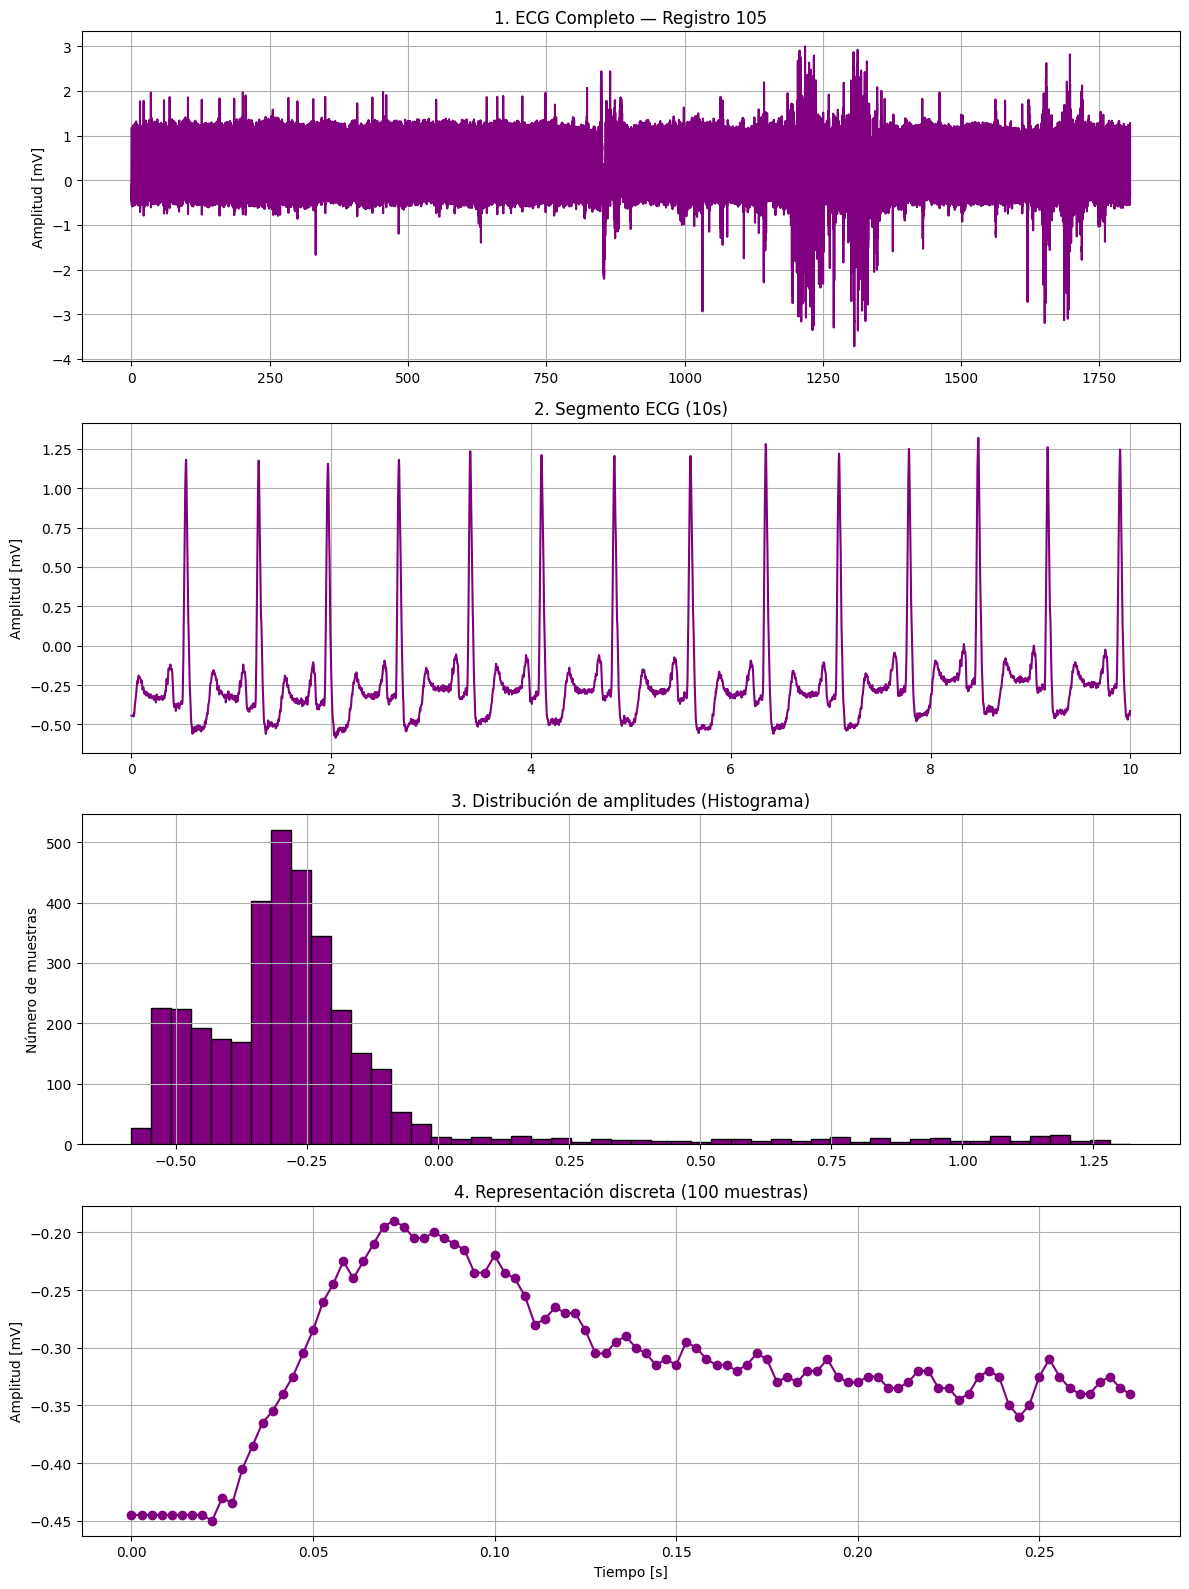

In [20]:
NUEVO_RECORD = "105"
nuevo_record = wfdb.rdrecord(NUEVO_RECORD, pn_dir=DATABASE)
nuevo_fs = nuevo_record.fs
nueva_signal = nuevo_record.p_signal[:, CHANNEL]
nuevo_t = np.arange(len(nueva_signal)) / nuevo_fs

print(f"Registro analizado: {NUEVO_RECORD} | Canal: {nuevo_record.sig_name[CHANNEL]} | Frecuencia: {nuevo_fs} Hz")

# Configurar figura con 4 subgráficos
fig, axs = plt.subplots(4, 1, figsize=(12, 16))

# 1. Gráfica ECG Completo
axs[0].plot(nuevo_t, nueva_signal, color='purple')
axs[0].set_title(f"1. ECG Completo — Registro {NUEVO_RECORD}")
axs[0].set_ylabel(f"Amplitud [{nuevo_record.units[CHANNEL]}]")
axs[0].grid(True)

# 2. Segmento de 10 segundos
N_seg = int(10 * nuevo_fs)
nuevo_t_seg = nuevo_t[:N_seg]
nueva_signal_seg = nueva_signal[:N_seg]

axs[1].plot(nuevo_t_seg, nueva_signal_seg, color='purple')
axs[1].set_title(f"2. Segmento ECG (10s)")
axs[1].set_ylabel(f"Amplitud [{nuevo_record.units[CHANNEL]}]")
axs[1].grid(True)

# 3. Histograma
axs[2].hist(nueva_signal_seg, bins=50, color='purple', edgecolor='black')
axs[2].set_title("3. Distribución de amplitudes (Histograma)")
axs[2].set_ylabel("Número de muestras")
axs[2].grid(True)

# 4. Representación discreta (100 muestras)
N_SAMPLES = 100
axs[3].plot(nuevo_t_seg[:N_SAMPLES], nueva_signal_seg[:N_SAMPLES], marker="o", color='purple')
axs[3].set_title(f"4. Representación discreta ({N_SAMPLES} muestras)")
axs[3].set_xlabel("Tiempo [s]")
axs[3].set_ylabel(f"Amplitud [{nuevo_record.units[CHANNEL]}]")
axs[3].grid(True)

plt.tight_layout()
plt.show()

**Comparación: Registro 100 vs. Registro 105**

*   **Frecuencia de muestreo y número de canales:** Ambos registros son idénticos en este aspecto; mantienen una frecuencia de 360 Hz y poseen 2 canales. Esto se debe a que ambos pertenecen a la misma base estandarizada (MIT-BIH Arrhythmia Database).
*   **Nombres de canales:** Aquí hay una diferencia clave. Mientras el registro original (100) utilizaba la derivación "MLII" para el canal 0, el nuevo registro (105) utiliza la derivación "V1".
*   **Morfología:** La forma de la onda cambia drásticamente. Al ser una derivación distinta (V1 en lugar de MLII), el complejo QRS en el registro 105 presenta una deflexión predominantemente negativa (onda S profunda), en contraste con el pico positivo y alto del registro 100.
*   **Amplitud:** El rango de voltaje también difiere. La excursión del voltaje en el registro 105 tiene un alcance distinto, reflejando la proyección eléctrica del corazón desde otro ángulo espacial.
*   **Distribución (Histograma):** La distribución de las amplitudes del registro 105 es asimétrica y presenta una cola extendida hacia los valores negativos, lo cual es coherente con la predominancia de deflexiones negativas en su morfología, a diferencia del histograma del registro 100 que tenía colas hacia valores positivos por las ondas R altas.

## Ejercicio 2 — Cambiar de canal

Modifique:

```python
CHANNEL = 0
```

por otro canal disponible.

Responda:

1. ¿Qué nombre tiene el nuevo canal?
2. ¿Tiene las mismas unidades?
3. ¿La morfología es igual?
4. ¿Qué diferencias observa?

---


Canal analizado: 1 (V5)


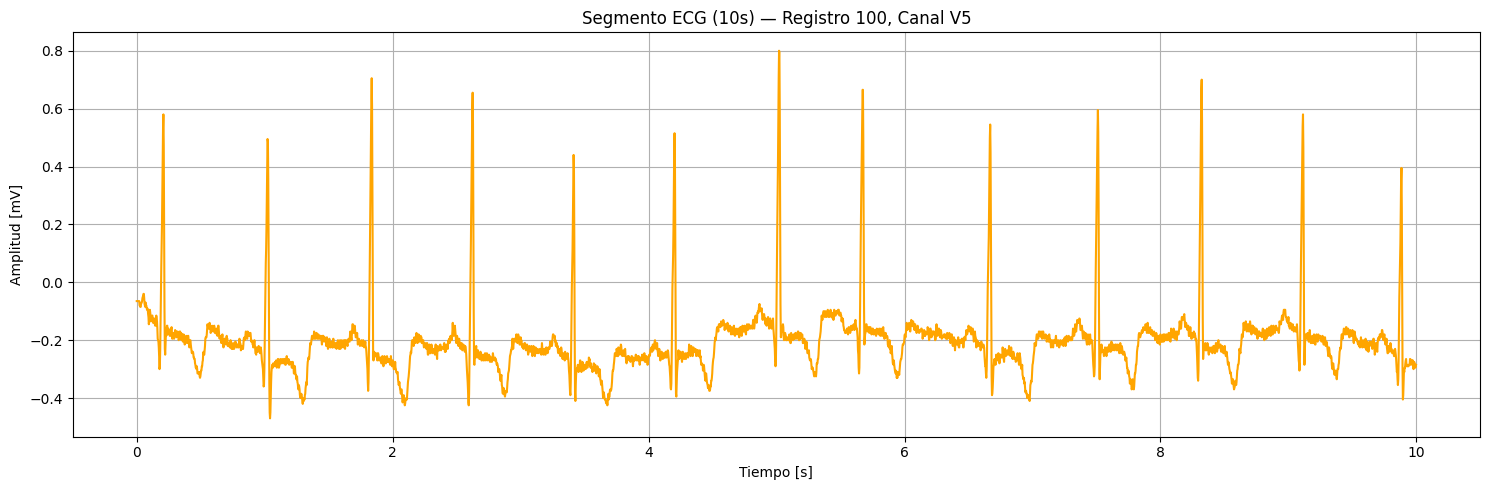

In [21]:
# Se retoma el registro original "100", pero cambiamos al canal 1
CHANNEL_EJ2 = 1
signal_ej2 = record.p_signal[:, CHANNEL_EJ2]
nombre_canal_ej2 = record.sig_name[CHANNEL_EJ2]
unidades_ej2 = record.units[CHANNEL_EJ2]

print(f"Canal analizado: {CHANNEL_EJ2} ({nombre_canal_ej2})")

# Seleccionamos un segmento de 10 segundos
N_ej2 = int(10 * fs)
signal_segment_ej2 = signal_ej2[:N_ej2]
t_segment_ej2 = t[:N_ej2]

# Generar la gráfica
plt.figure(figsize=(15, 5))
plt.plot(t_segment_ej2, signal_segment_ej2, color='orange')
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{unidades_ej2}]")
plt.title(f"Segmento ECG (10s) — Registro {RECORD}, Canal {nombre_canal_ej2}")
plt.grid(True)
plt.tight_layout()
plt.show()


1. **¿Qué nombre tiene el nuevo canal?** El nuevo canal correspondiente al índice 1 se denomina "V5".
2. **¿Tiene las mismas unidades?** Sí, mantiene exactamente las mismas unidades en milivoltios (mV).
3. **¿La morfología es igual?** No, la morfología de la señal varía significativamente. Al cambiar de derivación (de MLII a V5), se modifica el ángulo desde el cual los electrodos leen la actividad eléctrica del corazón.
4. **¿Qué diferencias observa?** Se aprecian cambios en la forma y proporción de las ondas. En el canal V5, la onda R sigue siendo positiva pero es mucho más "picuda" y angosta, y las ondas S son más profundas en comparación con el canal MLII.


## Ejercicio 3 — Cambiar la duración

Pruebe:

```python
DURATION = 5
```



```python
DURATION = 20
```

y compare las visualizaciones.

Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.


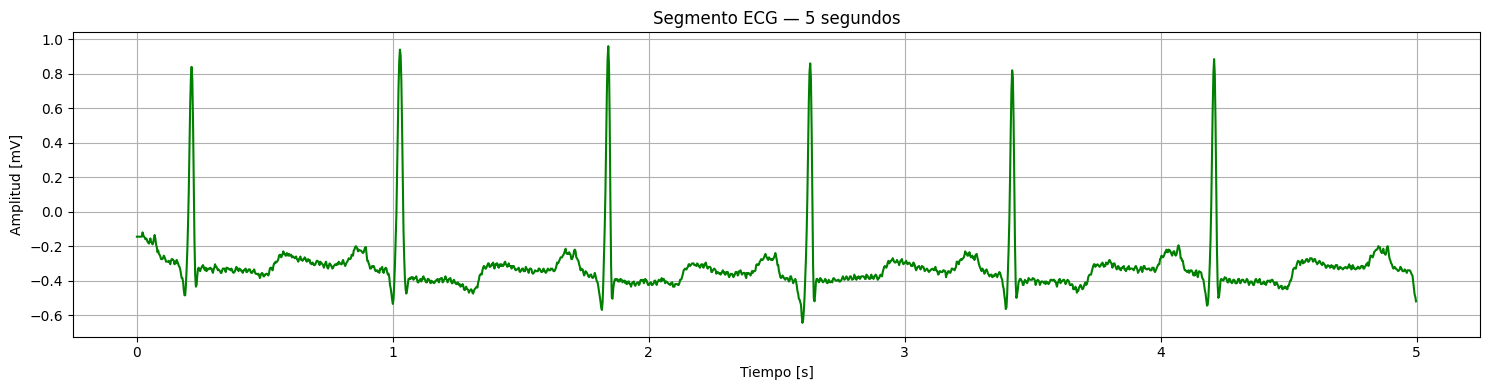

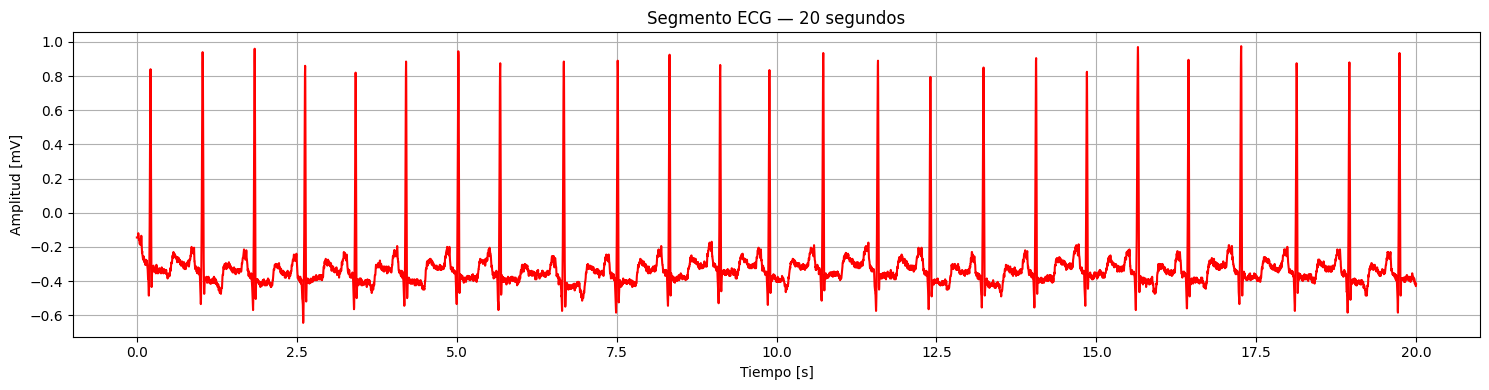

In [22]:
# Gráfica para 5 segundos
N_5 = int(5 * fs)
plt.figure(figsize=(15, 4))
plt.plot(t[:N_5], signal[:N_5], color='green')
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title("Segmento ECG — 5 segundos")
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfica para 20 segundos
N_20 = int(20 * fs)
plt.figure(figsize=(15, 4))
plt.plot(t[:N_20], signal[:N_20], color='red')
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title("Segmento ECG — 20 segundos")
plt.grid(True)
plt.tight_layout()
plt.show()

**Análisis y Comparación (5s vs. 20s):**

* **Duración de 5 segundos:** Al ser una ventana corta, nos permite hacer un "zoom" temporal y visualizar con gran detalle la morfología exacta de cada latido (identificando claramente las ondas P, el complejo QRS y la onda T). Sin embargo, se pierde el panorama general, siendo insuficiente para evaluar si el ritmo cardíaco es regular a largo plazo o para detectar arritmias espaciadas.
* **Duración de 20 segundos:** Por el contrario, esta vista proporciona una excelente perspectiva del ritmo global del corazón y la frecuencia de los latidos a lo largo del tiempo. La desventaja es que los ciclos se comprimen visualmente, lo que dificulta significativamente el análisis clínico de los detalles finos (morfología) de un latido individual.

**Conclusión:**
Una duración demasiado pequeña resta contexto sobre el ritmo global y la variabilidad cardíaca, mientras que una duración demasiado grande satura la gráfica visualmente impidiendo el análisis morfológico. En la práctica clínica y de ingeniería biomédica, se utilizan ventanas intermedias (como el estándar de 10 segundos) para lograr un equilibrio óptimo entre el detalle morfológico y el contexto del ritmo.

Duración solicitada : 5 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 1800


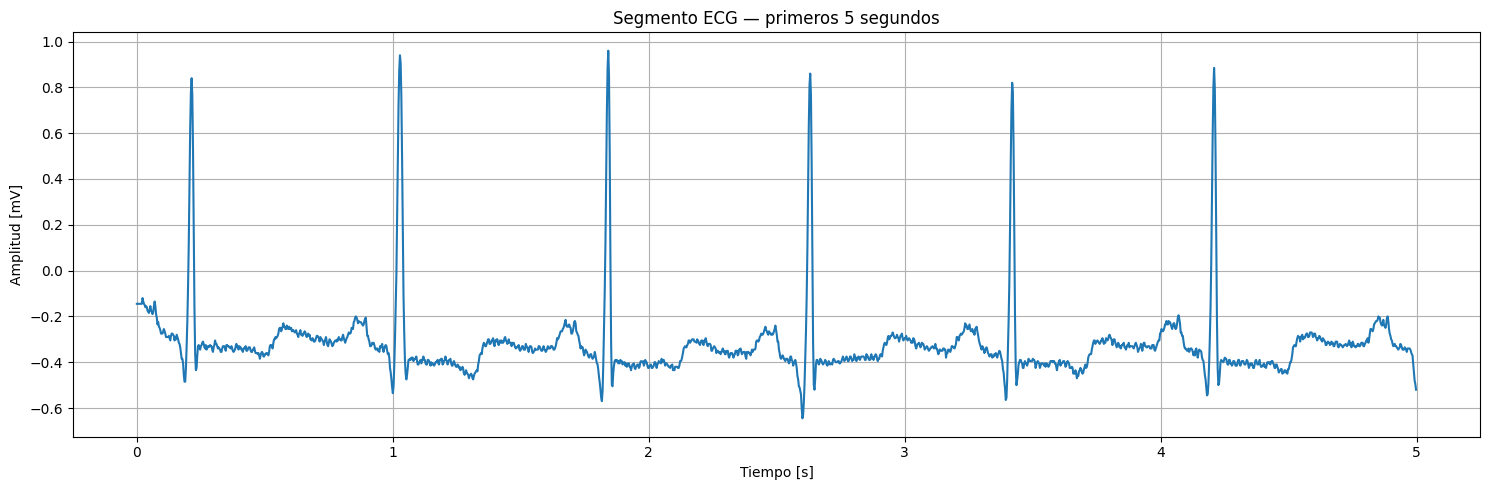

In [23]:
DURATION = 5

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment_5 = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

# ============================================
# GRÁFICA : SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment_5, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

Al utilizar una duración de 5 segundos, se observa un segmento corto de la señal ECG. Esto permite analizar con mayor detalle la forma de las ondas y los diferentes complejos cardíacos, pero se dispone de menos información sobre la señal a lo largo del tiempo.

Duración solicitada : 20 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 7200


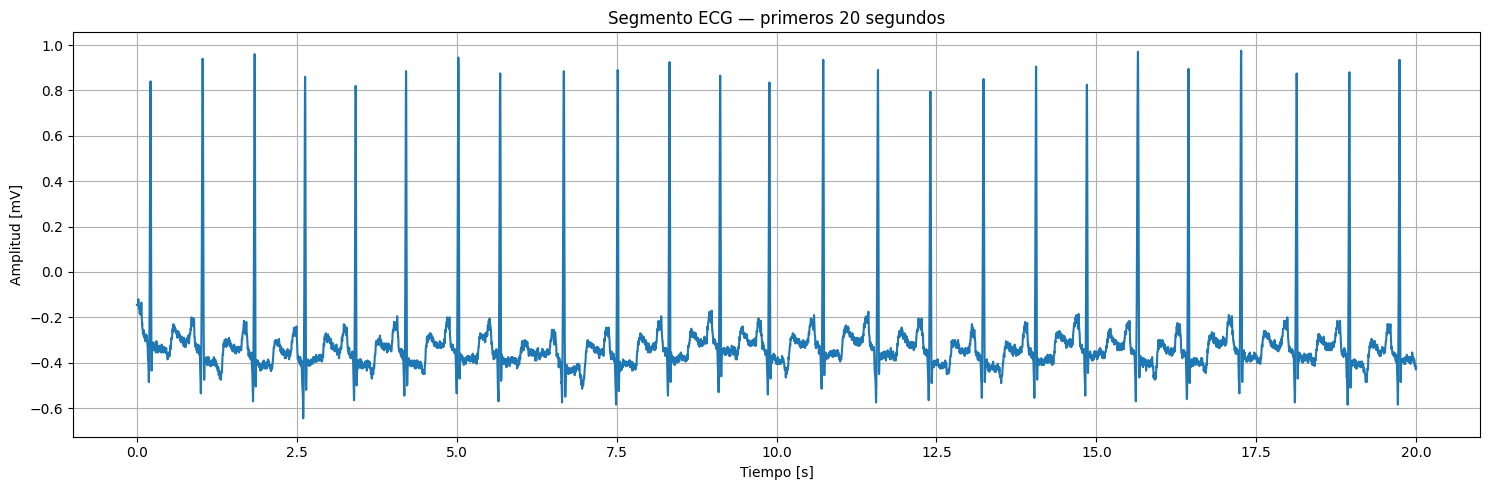

In [24]:
DURATION = 20

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment_20 = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

# ============================================
# GRÁFICA : SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment_20, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

Al utilizar una duración de 20 segundos, se puede observar una mayor cantidad de ciclos cardíacos y tener una visión más general del comportamiento de la señal. Sin embargo, al mostrar una señal más extensa, algunos detalles pueden ser más difíciles de distinguir visualmente.

**Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.**

Una duración demasiado pequeña puede dificultar el análisis porque no permite observar suficientes ciclos cardíacos ni identificar fácilmente variaciones o patrones en la señal. Por otro lado, una duración demasiado grande puede hacer que la gráfica se vea saturada y que los detalles de las ondas sean menos visibles.


## Ejercicio 4 — Frecuencia de muestreo

Suponga que:

$
f_s = 360\ Hz
$

### a)

Calcule el periodo de muestreo:

$
T_s = \frac{1}{f_s}
$

Se calcula como:

$
T_s=\frac{1}{f_s}=\frac{1}{360}=0.00278\ s
$

Por lo tanto, el periodo de muestreo es 0.00278 s o 2.78 ms.

### b)

¿Cuántas muestras existen en 5 segundos?

$
N=f_s\times t=360\times5=1800
$

Por lo tanto, existen 1800 muestras en 5 segundos.

### c)

¿Cuántas muestras existen en 10 segundos?

$
N=f_s\times t=360\times10=3600
$

Por lo tanto, existen 3600 muestras en 10 segundos.

### d)

Explique qué sucedería si la frecuencia de muestreo fuese reducida significativamente.

Si la frecuencia de muestreo se reduce significativamente, se obtienen menos muestras por segundo y la señal tendrá una menor resolución temporal. Si la frecuencia es demasiado baja, puede producirse aliasing y la señal no se representará correctamente.

---

## Ejercicio 5 — Análisis de amplitud

Utilizando el segmento seleccionado:

1. Calcule la media.
2. Calcule la desviación estándar.
3. Determine el máximo.
4. Determine el mínimo.
5. Calcule el rango.

Explique qué información proporciona cada parámetro.


**Respuestas del Ejercicio 5:**

Basado en el segmento analizado del registro 100:

1. **Media (-0.3199 mV):** Nos indica el voltaje promedio de la señal. Sirve para identificar dónde está ubicada la línea base o si hay algún nivel de corriente continua (DC) acumulado en los electrodos.
2. **Desviación estándar (0.1702 mV):** Mide la dispersión de los voltajes respecto a la media. Un valor alto indica fluctuaciones fuertes en la señal, lo que confirma la presencia de picos altos como los de los complejos QRS.
3. **Máximo (0.9600 mV):** Es el pico más alto alcanzado en la señal, que en este ECG corresponde a la cresta de la onda R durante la despolarización ventricular.
4. **Mínimo (-0.6450 mV):** Es el valor más profundo de voltaje registrado, asociado usualmente a las ondas S o Q del latido.
5. **Rango (1.6050 mV):** Es la diferencia total entre el voltaje máximo y el mínimo. Nos muestra la "altura" o excursión dinámica total de la señal, un dato vital para procesos posteriores de normalización.


# 19. Preguntas conceptuales

Responda con sus propias palabras.

### 1. ¿Qué es PhysioNet?
- PhysioNet es una plataforma de acceso abierto (open access) desarrollada por el Laboratorio de Fisiología Computacional del MIT y el Beth Israel Deaconess Medical Center. Su objetivo principal es facilitar la investigación en ingeniería biomédica, fisiología computacional y medicina de precisión, proporcionando bases de datos de señales fisiológicas reales junto con herramientas de software para su procesamiento. En esta plataforma se pueden encontrar registros de ECG, EEG, EMG, señales de presión arterial, entre otras, muchas de ellas con anotaciones clínicas validadas por especialistas. Para este laboratorio, PhysioNet fue fundamental porque nos permitió acceder directamente al registro 100 de la MIT-BIH Arrhythmia Database sin necesidad de descargar archivos manualmente, utilizando únicamente la librería WFDB.

### 2. ¿Qué diferencia existe entre `DATABASE` y `RECORD`?

- DATABASE es toda la coleccion de registros que comparten la misma metodologia. Por ejemplo, mitdb es la base MIT-BIH que tiene 48 ECG de pacientes con arritmias, todos tomados a 360 Hz. RECORD es el numero de un solo paciente dentro de esa base. El 100 es el ECG de una persona especifica.No podemos decir solo "registro 100" porque ese numero podria existir en otra base de datos con caracteristicas distintas. Siempre hay que decir base mas registro. La base da el contexto tecnico y el registro es la senal individual.

### 3. ¿Qué representa `fs`?
- Es la frecuencia de muestreo. Indica cuántas muestras (o valores discretos) toma el equipo médico por cada segundo para convertir la señal analógica del corazón en una señal digital.

### 4. ¿Qué representa `CHANNEL`?
- Es el índice que utilizamos para elegir qué derivación específica queremos extraer de los datos. Como el ECG se mide con varios electrodos a la vez, cada canal representa una "vista" o ángulo espacial diferente de la actividad eléctrica del corazón.

### 5. ¿Qué representa `record.p_signal`?
- Es la matriz que contiene los datos físicos de la señal eléctrica. Las filas representan el tiempo (las muestras adquiridas) y las columnas representan las distintas derivaciones o canales, ya con sus valores reales en milivoltios.

### 8. ¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?
- Porque al convertir la señal a WAV, modificamos su escala natural. El WAV almacena números enteros sin unidades para que la computadora los procese como sonido, por lo que perdemos la escala clínica real en milivoltios (mV). Además, auditivamente es imposible distinguir las morfologías clave (ondas P, QRS, T) necesarias para un diagnóstico.

### 9. ¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?
- Las señales reales incluyen imperfecciones del mundo físico, como la variabilidad de la frecuencia cardíaca, cambios en la línea base por la respiración del paciente e interferencias de la red eléctrica. Trabajar con estos datos nos entrena para filtrar y procesar información en un escenario clínico realista.

### 10. ¿Qué dificultades encontró durante el laboratorio?
- La principal dificultad fue comprender el preprocesamiento necesario (eliminar la componente DC y normalizar) para adaptar la matriz de números decimales de la señal a un formato entero de 16 bits, evitando así distorsionar los datos al exportarlos como audio WAV.


# 20. Reto final

Seleccione un registro diferente y realice el siguiente análisis:

```text
PhysioNet
   ↓
Seleccionar RECORD
   ↓
Identificar canales
   ↓
Seleccionar canal ECG
   ↓
Analizar 10 segundos
   ↓
Gráfica ECG
   ↓
Histograma
   ↓
Representación discreta
   ↓
Estadística
   ↓
Exportar WAV
```

### Informe

Presente:

1. Identificación de la base de datos.
2. Identificación del registro.
3. Frecuencia de muestreo.
4. Canal seleccionado.
5. Duración analizada.
6. Las 4 gráficas.
7. Estadísticas.
8. Archivo WAV.
9. Interpretación de los resultados.
10. Conclusiones.


INFORME DEL RETO FINAL
1. Base de datos      : mitdb
2. Registro           : 105
3. Frecuencia muestreo: 360 Hz
4. Canal seleccionado : 0 (MLII)
5. Duración analizada : 10 segundos
--------------------------------------------------
7. Estadísticas del Segmento:
   Media              : -0.2376 mV
   Desv. Estándar     : 0.3014 mV
   Rango (Max - Min)  : 1.9050 mV
--------------------------------------------------
8. Archivo WAV exportado: reto_ecg_105_ch0.wav


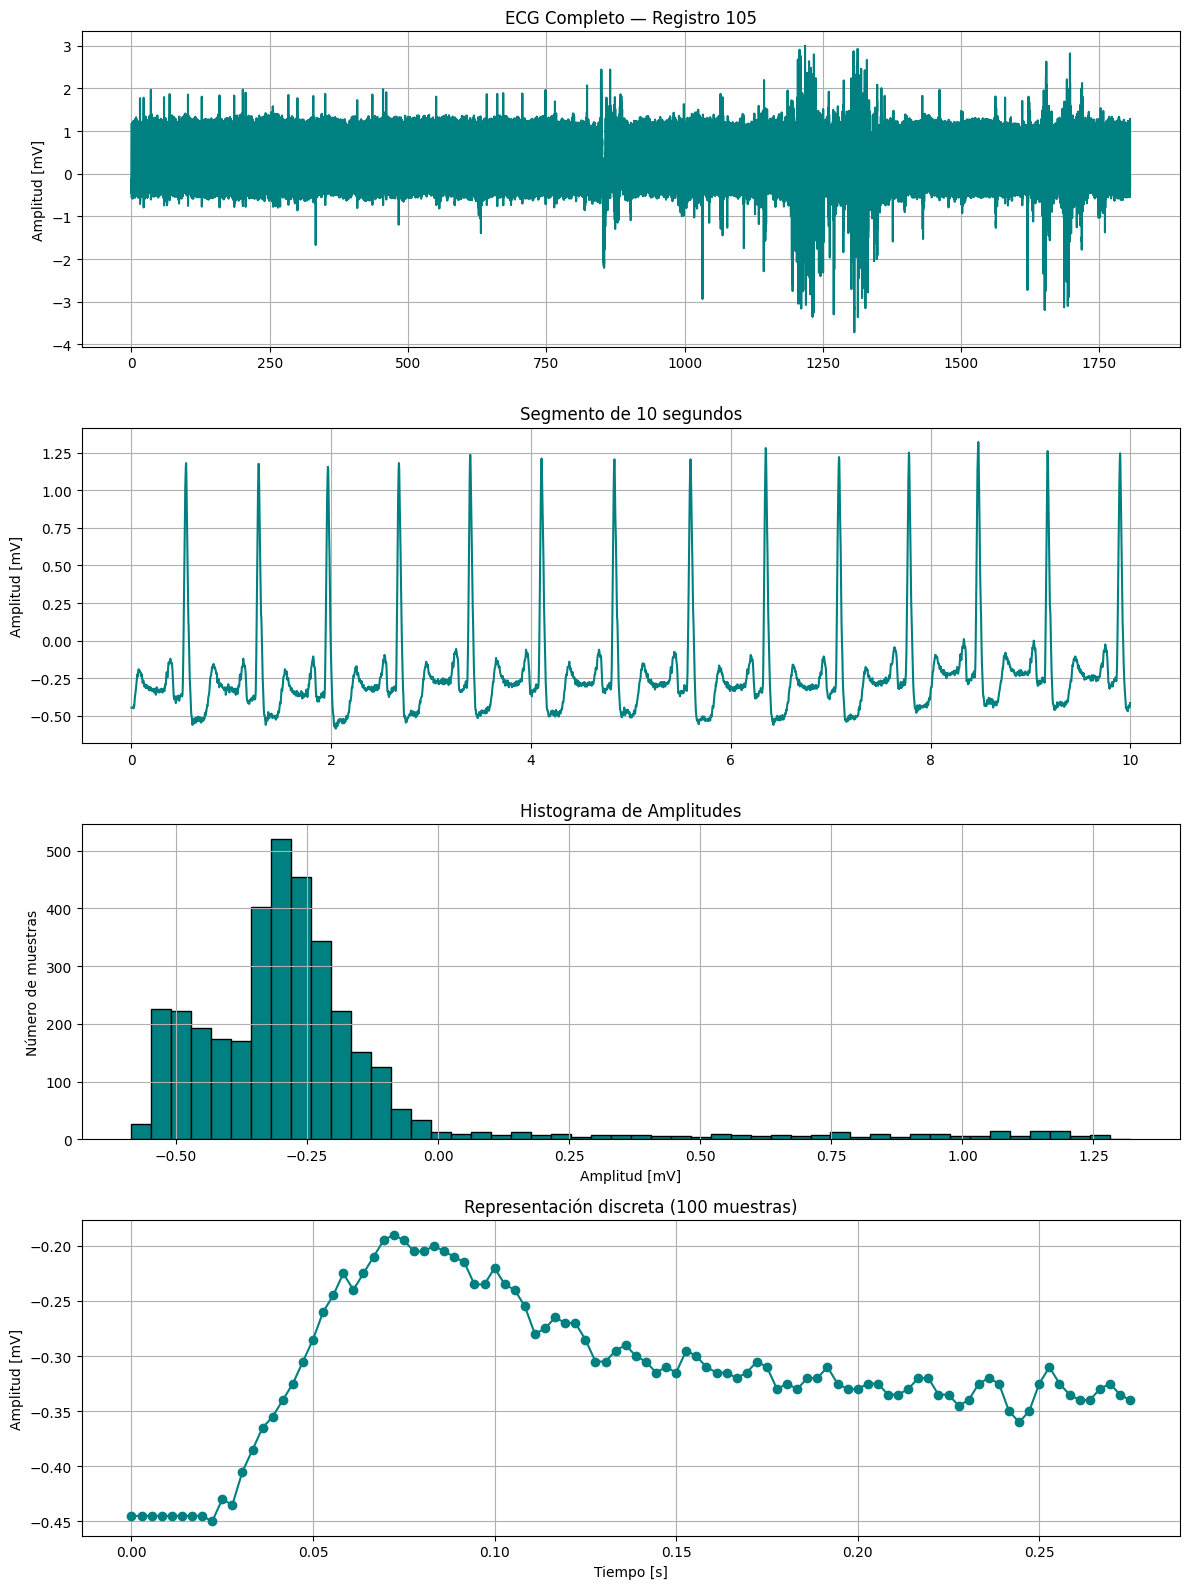

In [25]:
# 1, 2, 3, 4 y 5. Identificación y extracción
RETO_REC = "105"
record_final = wfdb.rdrecord(RETO_REC, pn_dir=DATABASE)
fs_final = record_final.fs
canal_nombre = record_final.sig_name[CHANNEL]
sig_final = record_final.p_signal[:, CHANNEL]
t_final = np.arange(len(sig_final)) / fs_final

# Selección del segmento (10s)
N_final = int(10 * fs_final)
sig_seg_final = sig_final[:N_final]
t_seg_final = t_final[:N_final]

# Imprimir Informe textual
print("=" * 50)
print("INFORME DEL RETO FINAL")
print("=" * 50)
print(f"1. Base de datos      : {DATABASE}")
print(f"2. Registro           : {RETO_REC}")
print(f"3. Frecuencia muestreo: {fs_final} Hz")
print(f"4. Canal seleccionado : {CHANNEL} ({canal_nombre})")
print(f"5. Duración analizada : 10 segundos")

# 7. Estadísticas
r_mean = np.mean(sig_seg_final)
r_std = np.std(sig_seg_final)
r_min = np.min(sig_seg_final)
r_max = np.max(sig_seg_final)
print("-" * 50)
print("7. Estadísticas del Segmento:")
print(f"   Media              : {r_mean:.4f} mV")
print(f"   Desv. Estándar     : {r_std:.4f} mV")
print(f"   Rango (Max - Min)  : {(r_max - r_min):.4f} mV")

# 8. Exportar WAV
ecg_norm = (sig_seg_final.astype(float) - r_mean) / np.max(np.abs(sig_seg_final.astype(float) - r_mean))
ecg_wav = np.int16(ecg_norm * 32767)
nombre_wav = f"reto_ecg_{RETO_REC}_ch{CHANNEL}.wav"
wavfile.write(nombre_wav, int(fs_final), ecg_wav)
print("-" * 50)
print(f"8. Archivo WAV exportado: {nombre_wav}")
print("=" * 50)

# 6. Las 4 Gráficas
fig, axs = plt.subplots(4, 1, figsize=(12, 16))

axs[0].plot(t_final, sig_final, color='teal')
axs[0].set_title(f"ECG Completo — Registro {RETO_REC}")
axs[0].set_ylabel("Amplitud [mV]")
axs[0].grid(True)

axs[1].plot(t_seg_final, sig_seg_final, color='teal')
axs[1].set_title("Segmento de 10 segundos")
axs[1].set_ylabel("Amplitud [mV]")
axs[1].grid(True)

axs[2].hist(sig_seg_final, bins=50, color='teal', edgecolor='black')
axs[2].set_title("Histograma de Amplitudes")
axs[2].set_xlabel("Amplitud [mV]")
axs[2].set_ylabel("Número de muestras")
axs[2].grid(True)

axs[3].plot(t_seg_final[:100], sig_seg_final[:100], marker="o", color='teal')
axs[3].set_title("Representación discreta (100 muestras)")
axs[3].set_xlabel("Tiempo [s]")
axs[3].set_ylabel("Amplitud [mV]")
axs[3].grid(True)

plt.tight_layout()
plt.show()

### 9. Interpretación de resultados y 10. Conclusiones

* **Interpretación:** Al analizar detalladamente el registro 105 (derivación V1), se observa que la morfología de la señal es drásticamente distinta a la del registro 100, predominando las deflexiones negativas (ondas S profundas). Esta asimetría morfológica se refleja directamente en el histograma. Asimismo, la gráfica de representación discreta demuestra que la frecuencia de muestreo de 360 Hz (periodo de ~2.78 ms) es lo suficientemente alta para capturar y reconstruir la dinámica del voltaje sin riesgo evidente de *aliasing*.
* **Conclusión:** El procesamiento de señales biomédicas requiere una comprensión profunda del contexto de adquisición (frecuencia de muestreo, tipo de derivación, base de datos). Adicionalmente, se comprueba que etapas de preprocesamiento, como la supresión del nivel de continua (DC) y la normalización de la amplitud, son pasos algorítmicos indispensables antes de transformar los datos a otros dominios o formatos (como archivos de audio WAV) para evitar pérdida de información y saturación digital.


# 21. Conclusiones esperadas

Al finalizar el laboratorio, el estudiante debería comprender que una señal biomédica puede estudiarse desde diferentes perspectivas:

```text
              SEÑAL ECG
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     Tiempo    Amplitud   Distribución
       │          │          │
       └──────────┼──────────┘
                  ↓
          Señal discreta x[n]
                  ↓
          Procesamiento digital
                  ↓
        Filtros FIR / IIR
                  ↓
         Análisis de señales
```

Este laboratorio constituye la base para los siguientes laboratorios, donde se aplicarán técnicas de **procesamiento digital de señales**, incluyendo filtros FIR, filtros IIR, respuesta en frecuencia y Transformada Z.



# Referencias

- PhysioNet — plataforma de acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas Python para lectura y procesamiento de registros fisiológicos.
- MIT-BIH Arrhythmia Database — base de datos utilizada como ejemplo en este laboratorio.

**Nota:** consulte siempre la documentación oficial de la base de datos seleccionada para conocer el significado de sus registros, canales y anotaciones.
